# 10 — Punti residui del Caso C e checklist v0.14

Il report fino alla v0.13 (notebook 04–09) lasciava quattro punti aperti o non indagati. Questo notebook
ne mostra gli esiti, che nel report stanno in §13:

- **A.** coverage al 90% di $\mu_E$ a N = 300, al limite (0.84 sui seed della checklist);
- **B.** $\Omega_n$ sovra-confidente a N = 50: coverage HPD 0.86 al 90%, pull rms 1.08;
- **C.** differenza di 1–2 esperimenti su 40 fra §8.3 e §9 a N = 1000;
- **D.** margine del test di integrazione (N = 60, soglia 15°) e mancanza di un test di regressione a N alto.

Il notebook legge solo risultati già salvati in `outputs/`, senza run pesanti. Li producono:

| pkl | script |
|---|---|
| `caso_C_checklist_results_v0.13.pkl`, `caso_C_checklist_results.pkl` (v0.14) | `scripts/caso_C_checklist.py` |
| `caso_C_cov68_results.pkl` (tag 68) | `scripts/caso_C_cov68.py` |
| `caso_C_cov90_mu_results.pkl` (tag 90) | `scripts/caso_C_cov90_mu.py` |
| `caso_C_diag_omega_N50[_tag50, _tag51].pkl` | `scripts/caso_C_diag_omega_N50.py` |
| `caso_C_diag_stadio1_test.pkl` | `scripts/caso_C_diag_stadio1_test.py` |

Il run col tag 50 è stato fatto prima di aggiungere le varianti "predittiva" e "plug-in +1 sd", quindi ha solo plug-in e oracolo.
Etichette dei risultati: (a) fatto consolidato, (b) stima toy, (c) MC verificato, (d) ipotesi da testare.

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path("..") / "scripts"))
from caso_C_checklist import collect, rms
%matplotlib inline
from riptide_toy import validate

plt.rcParams["figure.dpi"] = 110
OUT = Path("..") / "outputs"


def load(name: str):
    """Carica un pkl da outputs/."""
    with open(OUT / name, "rb") as f:
        return pickle.load(f)


CHECK13, CHECK14 = load("caso_C_checklist_results_v0.13.pkl"), load("caso_C_checklist_results.pkl")
COV68, COV90 = load("caso_C_cov68_results.pkl"), load("caso_C_cov90_mu_results.pkl")
DIAG_B = {"checklist": load("caso_C_diag_omega_N50.pkl"), "tag 50": load("caso_C_diag_omega_N50_tag50.pkl"),
          "tag 51": load("caso_C_diag_omega_N50_tag51.pkl")}
DIAG_D = load("caso_C_diag_stadio1_test.pkl")
LEVELS = CHECK14["LEVELS"]


def binom_err(p: float, m: int) -> float:
    """Errore binomiale di una coverage p stimata su m esperimenti."""
    return float(np.sqrt(p * (1 - p) / m))

## A. Coverage al 90% di $\mu_E$ a N = 300 (c)

Tre insiemi di seed disgiunti: la checklist (M = 100), il run di §12 (tag 68, M = 300) e un run dedicato
(tag 90, M = 600). Lo stadio 2 è lo stesso in tutti, su $\hat\Omega_0$ dello stadio 1. Nel run col tag 90
è calcolato anche sulla $\Omega$ vera, per separare il contributo dello stadio 1.

In [2]:
def mu_rows(pkl: dict, which: str = "hat") -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """mu_true, mu_int (M, livelli, 2), mu_mean, mu_std a N = 300 da un pkl di cov68/cov90."""
    rows = [r for r in pkl["results"] if r["N"] == 300]
    return (np.array([r["mu_true"] for r in rows]), np.array([r[which]["mu_int"] for r in rows]),
            np.array([r[which]["mu_mean"] for r in rows]), np.array([r[which]["mu_std"] for r in rows]))


c300 = collect(CHECK14["results"], 300)
SETS_A = {"checklist": (c300["mu_true"], c300["mu_int"], c300["mu_mean"], c300["mu_std"]),
          "tag 68": mu_rows(COV68), "tag 90, Ω̂₀": mu_rows(COV90), "tag 90, Ω vera": mu_rows(COV90, "true")}
cov_A = {}
for name, (truth, intervals, mean, std) in SETS_A.items():
    _, cov = validate.coverage_curve(truth, intervals, LEVELS)
    pull = (mean - truth) / std
    cov_A[name] = (cov, truth.size)
    print(f"{name:15s} M={truth.size:3d} coverage {np.round(cov, 3)}  "
          f"cov90 = {cov[1]:.3f} ± {binom_err(cov[1], truth.size):.3f}  pull media {pull.mean():+.2f} sd {pull.std():.2f}")

pooled = {"tag 68 + 90": ("tag 68", "tag 90, Ω̂₀"), "tutti (Ω̂₀)": ("checklist", "tag 68", "tag 90, Ω̂₀")}
for name, keys in pooled.items():
    m = sum(cov_A[k][1] for k in keys)
    p = sum(cov_A[k][0][1] * cov_A[k][1] for k in keys) / m
    print(f"pooled {name:12s} M={m}: cov90 = {p:.3f} ± {binom_err(p, m):.4f}  (z = {(p - 0.90) / binom_err(0.90, m):+.1f})")

checklist       M=100 coverage [0.66 0.84 0.91]  cov90 = 0.840 ± 0.037  pull media -0.02 sd 1.14
tag 68          M=300 coverage [0.69  0.877 0.933]  cov90 = 0.877 ± 0.019  pull media -0.09 sd 1.03
tag 90, Ω̂₀     M=600 coverage [0.7   0.897 0.955]  cov90 = 0.897 ± 0.012  pull media +0.08 sd 1.00
tag 90, Ω vera  M=600 coverage [0.697 0.9   0.955]  cov90 = 0.900 ± 0.012  pull media +0.07 sd 1.00
pooled tag 68 + 90  M=900: cov90 = 0.890 ± 0.0104  (z = -1.0)
pooled tutti (Ω̂₀)  M=1000: cov90 = 0.885 ± 0.0101  (z = -1.6)


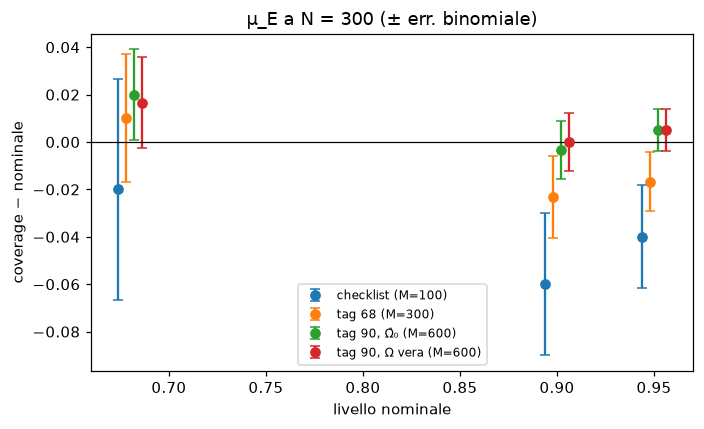

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for k, (name, (cov, m)) in enumerate(cov_A.items()):
    err = np.sqrt(LEVELS * (1 - LEVELS) / m)
    ax.errorbar(LEVELS + 0.004 * (k - 1.5), cov - LEVELS, yerr=err, fmt="o", capsize=3, label=f"{name} (M={m})")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="livello nominale", ylabel="coverage − nominale", title="μ_E a N = 300 (± err. binomiale)")
ax.legend(fontsize=8)
fig.tight_layout()

Sui 900 seed nuovi la coverage al 90% è entro circa 1 errore binomiale dal nominale, e l'sd dei pull
vale 1.00. Con $\hat\Omega_0$ o con la $\Omega$ vera i risultati sono indistinguibili. Lo 0.84 della checklist
è una **fluttuazione (c)**: $\mu_E$ è calibrato a N = 300.

## B. $\Omega_n$ sovra-confidente a N = 50 (c)

Lo stadio 1′ è rifatto sugli stessi dati con quattro prior gaussiani su $E_n$:

- **plug-in** $\mathcal N(\mathbb E[\mu],\ e^{\mathbb E[\log\sigma]})$, usato dalla checklist fino alla v0.13;
- **oracolo** $\mathcal N(\mu_\text{true}, \sigma_\text{true})$, il riferimento;
- **predittiva** $\mathcal N\big(\mathbb E[\mu],\ \sqrt{\mathbb E[\sigma^2] + \mathrm{Var}[\mu]}\big)$ (`posterior_C.predictive_energy_moments`), usata dalla v0.14;
- **plug-in +1 sd** $\mathcal N(\mathbb E[\mu],\ e^{\mathbb E[\log\sigma] + \mathrm{std}[\log\sigma]})$.

### B2/B3: verità fuori calotta e massa al bordo

La coverage della checklist richiede che la verità stia dentro la calotta (`truth_in_cap`). Se la calotta
la escludesse (B2), o tagliasse la posterior (B3), la sotto-copertura sarebbe un artefatto della misura.

In [4]:
for name, pkl in DIAG_B.items():
    res = pkl["results"]
    for v in (k for k in ("largo", "plugin", "oracolo", "predittiva", "plugin_+1sd") if k in res[0]):
        rows = [r[v] for r in res]
        print(f"{name:9s} [{v:11s}] M={len(rows)}: verità fuori calotta {sum(not r['in_cap'] for r in rows)}, "
              f"massa oltre 0.8 R max {max(r['edge_mass'] for r in rows):.1e}, "
              f"angolo verità / R max {max(r['true_angle_over_R'] for r in rows):.2f}")

checklist [largo      ] M=200: verità fuori calotta 0, massa oltre 0.8 R max 8.5e-07, angolo verità / R max 0.43
checklist [plugin     ] M=200: verità fuori calotta 0, massa oltre 0.8 R max 4.1e-11, angolo verità / R max 0.40
checklist [oracolo    ] M=200: verità fuori calotta 0, massa oltre 0.8 R max 7.0e-09, angolo verità / R max 0.40
checklist [predittiva ] M=200: verità fuori calotta 0, massa oltre 0.8 R max 1.2e-10, angolo verità / R max 0.36
checklist [plugin_+1sd] M=200: verità fuori calotta 0, massa oltre 0.8 R max 1.2e-09, angolo verità / R max 0.33
tag 50    [plugin     ] M=600: verità fuori calotta 0, massa oltre 0.8 R max 2.1e-10, angolo verità / R max 0.38
tag 50    [oracolo    ] M=600: verità fuori calotta 0, massa oltre 0.8 R max 4.0e-10, angolo verità / R max 0.36
tag 51    [plugin     ] M=600: verità fuori calotta 0, massa oltre 0.8 R max 6.4e-09, angolo verità / R max 0.33
tag 51    [oracolo    ] M=600: verità fuori calotta 0, massa oltre 0.8 R max 3.4e-08, angolo ver

La verità è sempre dentro la calotta e la massa nell'anello esterno è trascurabile: **B2 e B3 sono escluse (c)**.

### B1: il prior plug-in è troppo stretto

In [5]:
VARIANTS = ("plugin", "oracolo", "predittiva", "plugin_+1sd")
table_B = {}
for name, pkl in DIAG_B.items():
    res = pkl["results"]
    for v in (k for k in VARIANTS if k in res[0]):
        rows = [r[v] for r in res]
        cov = np.mean([r["cov"] for r in rows], axis=0)
        pull = validate.angular_pull(np.array([r["err"] for r in rows]), np.array([r["sigma"] for r in rows]))
        table_B[(name, v)] = (cov, len(rows))
        print(f"{name:9s} [{v:11s}] M={len(rows)} coverage HPD {np.round(cov, 3)}  pull rms {rms(pull):.2f}")

print()
for v in VARIANTS:
    parts = [table_B[(n, v)] for n in DIAG_B if (n, v) in table_B]
    m = sum(p[1] for p in parts)
    cov = sum(p[0] * p[1] for p in parts) / m
    z = (cov - LEVELS) / np.sqrt(LEVELS * (1 - LEVELS) / m)
    print(f"pooled [{v:11s}] M={m:4d} coverage {np.round(cov, 3)}  z {np.round(z, 1)}")

checklist [plugin     ] M=200 coverage HPD [0.7   0.86  0.925]  pull rms 1.08
checklist [oracolo    ] M=200 coverage HPD [0.695 0.89  0.93 ]  pull rms 1.04
checklist [predittiva ] M=200 coverage HPD [0.705 0.875 0.93 ]  pull rms 1.05
checklist [plugin_+1sd] M=200 coverage HPD [0.71  0.885 0.925]  pull rms 1.01
tag 50    [plugin     ] M=600 coverage HPD [0.65  0.88  0.943]  pull rms 1.06
tag 50    [oracolo    ] M=600 coverage HPD [0.658 0.892 0.958]  pull rms 1.02
tag 51    [plugin     ] M=600 coverage HPD [0.677 0.895 0.937]  pull rms 1.02
tag 51    [oracolo    ] M=600 coverage HPD [0.688 0.9   0.94 ]  pull rms 0.99
tag 51    [predittiva ] M=600 coverage HPD [0.692 0.907 0.95 ]  pull rms 0.98
tag 51    [plugin_+1sd] M=600 coverage HPD [0.722 0.93  0.957]  pull rms 0.93

pooled [plugin     ] M=1400 coverage [0.669 0.884 0.938]  z [-0.9 -2.  -2.1]
pooled [oracolo    ] M=1400 coverage [0.676 0.895 0.946]  z [-0.3 -0.6 -0.6]
pooled [predittiva ] M= 800 coverage [0.695 0.899 0.945]  z [ 0.9

tag 51: sd predittiva / sigma plug-in, mediana 1.093 [5%: 1.047, 95%: 2.301]


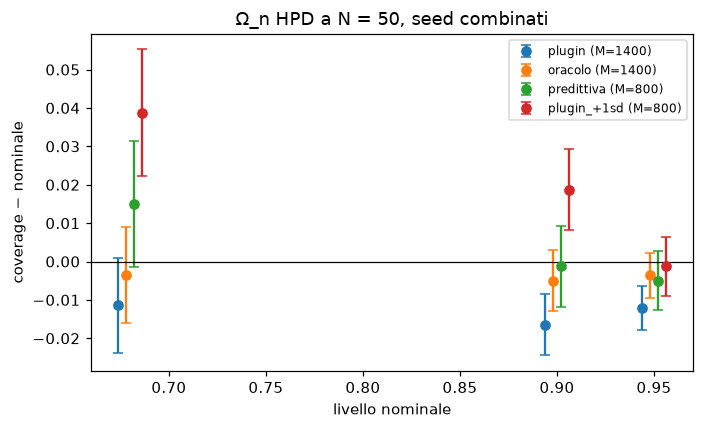

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for k, v in enumerate(VARIANTS):
    parts = [table_B[(n, v)] for n in DIAG_B if (n, v) in table_B]
    m = sum(p[1] for p in parts)
    cov = sum(p[0] * p[1] for p in parts) / m
    ax.errorbar(LEVELS + 0.004 * (k - 1.5), cov - LEVELS, yerr=np.sqrt(LEVELS * (1 - LEVELS) / m),
                fmt="o", capsize=3, label=f"{v} (M={m})")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="livello nominale", ylabel="coverage − nominale", title="Ω_n HPD a N = 50, seed combinati")
ax.legend(fontsize=8)
fig.tight_layout()

sig = np.concatenate([[r["sigma_plugin"] for r in DIAG_B["tag 51"]["results"]]])
pred = np.array([r["pred_sd"] for r in DIAG_B["tag 51"]["results"]])
print(f"tag 51: sd predittiva / sigma plug-in, mediana {np.median(pred / sig):.3f} "
      f"[5%: {np.percentile(pred / sig, 5):.3f}, 95%: {np.percentile(pred / sig, 95):.3f}]")

Il plug-in sotto-copre di circa 2 errori binomiali al 90% e al 95%. L'oracolo e la predittiva
sono nominali, mentre il plug-in +1 sd sovra-copre. La causa è **B1 in forma debole (c)**: il plug-in ignora
l'incertezza su $(\mu_E, \sigma_E)$, che a N = 50 non è trascurabile. La predittiva la propaga allo stesso
costo, ed è il prior dello stadio 1′ dalla v0.14.

## Checklist v0.13 contro v0.14

Stessi seed, stesso stadio 2; cambia solo il prior dello stadio 1′. Quindi $\mu_E$ e $\log\sigma_E$ devono
restare identici esperimento per esperimento, e cambiano solo le colonne di $\Omega_n$.

In [7]:
for n in (50, 150, 300, 1000):
    old, new = collect(CHECK13["results"], n), collect(CHECK14["results"], n)
    same = all(np.array_equal(old[k], new[k]) for k in ("mu_mean", "mu_int", "ls_median", "ls_int"))
    line = f"N={n:4d} M={new['mu_true'].size:3d}  mu/log sigma identici: {same}  |"
    for tag, t in (("v0.13", old), ("v0.14", new)):
        pull = validate.angular_pull(t["omega_error"], t["omega_sigma"])
        line += f"  {tag}: cov Ω {np.round(t['omega_covered'].mean(axis=0), 3)} pull rms {rms(pull):.2f}"
    print(line)

N=  50 M=200  mu/log sigma identici: True  |  v0.13: cov Ω [0.7   0.86  0.925] pull rms 1.08  v0.14: cov Ω [0.705 0.875 0.93 ] pull rms 1.05
N= 150 M=200  mu/log sigma identici: True  |  v0.13: cov Ω [0.65  0.875 0.93 ] pull rms 1.05  v0.14: cov Ω [0.65  0.885 0.93 ] pull rms 1.04
N= 300 M=100  mu/log sigma identici: True  |  v0.13: cov Ω [0.66 0.91 0.95] pull rms 1.00  v0.14: cov Ω [0.66 0.91 0.96] pull rms 1.00
N=1000 M= 40  mu/log sigma identici: True  |  v0.13: cov Ω [0.775 0.925 0.975] pull rms 0.89  v0.14: cov Ω [0.775 0.925 0.975] pull rms 0.89


A N = 50 la coverage al 90% sale da 0.860 a 0.875 e il pull rms scende da 1.08 a 1.05. A N = 150–300
cambia al più un esperimento o due per livello; a N = 1000 la coverage è identica. Sui 200 seed della checklist la differenza è entro gli errori binomiali: la prova della
correzione è il confronto a coppie sui 1400 seed della sezione B.

## C. Differenza fra §8.3 e §9 a N = 1000 (c)

Non serve un run: 8 seed a N = 1000 rigiocati con `OMP_NUM_THREADS=1` riproducono bit a bit la checklist,
e con 3 thread BLAS le differenze sono ≤ 1.3·10⁻¹⁵ con gli stessi flag di copertura. `src/` non era cambiato
fra i due commit, quindi la differenza viene dallo script diagnostico di §8.3, che non è stato conservato (report §13.3).
Per questo gli script delle diagnostiche B e D ora stanno in `scripts/`.

## D. Margine dei test dello stadio 1 (c)

N=  60 [global] M=200: mediana 2.8°, 95% 5.2°, max 7.4°; tempo mediano 0.3 s
N= 300 [refine] M=100: mediana 1.2°, 95% 2.1°, max 3.0°; tempo mediano 1.2 s
N=1000 [refine] M=100: mediana 0.6°, 95% 1.2°, max 1.3°; tempo mediano 4.1 s


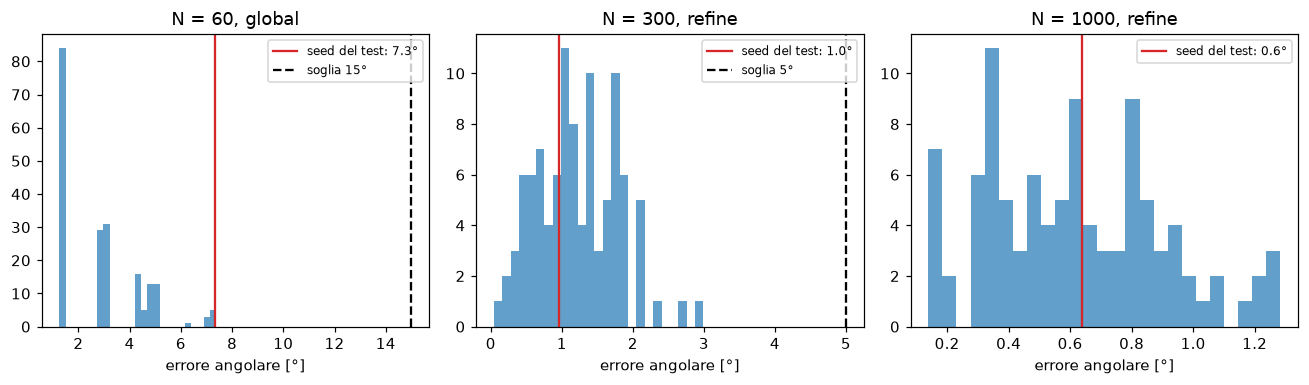

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (n, method, thr) in zip(axes, ((60, "global", 15.0), (300, "refine", 5.0), (1000, "refine", None))):
    rows = [r for r in DIAG_D if r[1] == n and r[2] == method]
    err = np.array([r[3] for r in rows])
    dt = np.array([r[4] for r in rows])
    ax.hist(err, bins=25, alpha=0.7)
    ax.axvline(rows[0][3], color="C3", label=f"seed del test: {rows[0][3]:.1f}°")
    if thr is not None:
        ax.axvline(thr, color="k", ls="--", label=f"soglia {thr:.0f}°")
    ax.set(title=f"N = {n}, {method}", xlabel="errore angolare [°]")
    ax.legend(fontsize=8)
    print(f"N={n:4d} [{method}] M={err.size}: mediana {np.median(err):.1f}°, 95% {np.percentile(err, 95):.1f}°, "
          f"max {err.max():.1f}°; tempo mediano {np.median(dt):.1f} s")
fig.tight_layout()

Il test end-to-end a N = 60 ha un margine di circa 2× sulla soglia di 15°, anche se la sua realizzazione
sta nella coda alta. L'errore a N = 60 è discreto perché `estimate_shared_direction` restituisce un pixel
della griglia globale. Il nuovo `test_stage1_error_contracts_at_large_N` usa N = 300 e una soglia di 5°: il
massimo su 100 seed è circa 3°, e il vecchio massimo sistematico a ~53° lo farebbe fallire. N = 1000 sarebbe
più stringente ma costa circa 4–5 s per test.

## Sintesi

| punto | esito | etichetta |
|---|---|---|
| A | coverage al 90% di $\mu_E$ nominale sui seed nuovi: fluttuazione | (c) |
| B | plug-in troppo stretto a N = 50; predittiva adottata in v0.14 | (c) |
| C | run deterministici; la differenza veniva dallo script perso di §8.3 | (c) |
| D | test a N = 60 con margine ~2×; nuovo test a N = 300 | (c) |

Nessun punto aperto sul Caso C (roadmap v0.14).